# Titanic Survival Analysis Using Data Visualization

**Name:** Tirth Laheri  
**Course:** DATA 6550

This notebook explores the Titanic dataset to better understand the factors that influenced passenger survival. The analysis begins with an overview of the dataset and basic data preparation before moving into exploratory data analysis and visualization. The project includes both **effective visualizations** that communicate meaningful insights and **misleading visualizations** that demonstrate how poor chart selection can make data more difficult to interpret. The overall goal is to use data visualization to present findings in a way that is clear, informative, and easy to understand.

# Section 1: Importing Libraries

The first step is to import the libraries required for data manipulation, analysis, and visualization. **Pandas** and **NumPy** are used for working with the dataset, while **Matplotlib** and **Seaborn** are used to create clear and informative visualizations.

In [17]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("All libraries are imported.")

All libraries are imported.


# Section 2: Loading the Dataset

The Titanic training dataset is loaded into a Pandas DataFrame for analysis. This dataset contains passenger information such as **age**, **gender**, **ticket class**, **fare**, **family relationships**, and **survival status**, which will be explored throughout this notebook.

In [19]:
#read the datasets

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
submission = pd.read_csv("data/gender_submission.csv")

In [20]:
#check the size of the datasets

print("Training dataset:", train.shape)
print("Test dataset:", test.shape)
print("Submission dataset:", submission.shape)

Training dataset: (891, 12)
Test dataset: (418, 11)
Submission dataset: (418, 2)


In [21]:
#preview the training dataset

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Section 3: Exploratory Data Analysis and Data Preparation

Before creating visualizations, it is important to understand the structure and quality of the dataset. In this section, the data is explored by examining its dimensions, variables, summary statistics, and missing values. Based on these observations, the necessary preprocessing steps are performed to prepare the data for analysis. Missing values are handled where appropriate, and new features such as **Family Size** and **Age Group** are created to support a more meaningful exploration of passenger survival patterns.

In [22]:
#dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
#summary statistics
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
#column names

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [25]:
#missing values

train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [26]:
#unique values in each column
train.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [27]:
#survival counts
train["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [28]:
#survival percentage
survival_percent = train["Survived"].value_counts(normalize=True) * 100
survival_percent.round(2)

,proportion
Survived,
0,61.62
1,38.38


# Section 4: Exploratory Data Visualizations

After exploring and preparing the dataset, the next step is to visualize the data to better understand the relationships between different passenger characteristics and survival. Data visualizations make it easier to identify patterns, compare groups, and communicate findings that may not be immediately obvious from summary statistics alone.

This section presents a series of visualizations that highlight important insights from the Titanic dataset. The first two examples demonstrate **effective visualizations** that clearly communicate meaningful patterns, while the final two examples illustrate **misleading visualizations** that can make the same data more difficult to interpret.

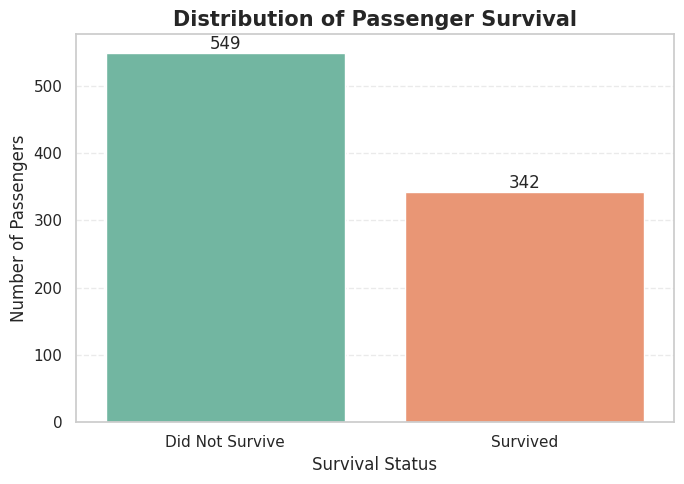

In [29]:
#survival distribution
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=train,
    x="Survived",
    hue="Survived",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Passenger Survival", fontsize=15, fontweight="bold")
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This bar chart shows the number of passengers who survived compared to those who did not survive the Titanic disaster. Out of **891 passengers**, **549 did not survive**, while **342 survived**, indicating that survival was less common.

This provides a quick overview of the dataset and establishes a starting point for the analysis. The following visualizations explore how factors such as **gender, age, passenger class, and family size** influenced these survival outcomes.

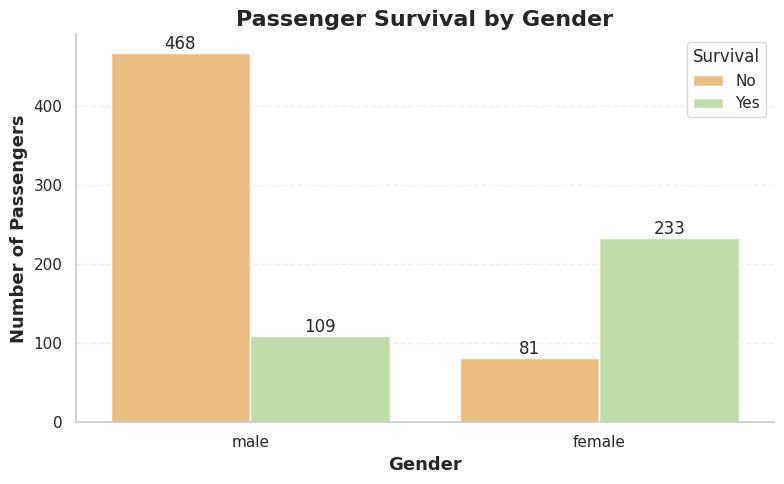

In [31]:
#gender vs survival

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=train,
    x="Sex",
    hue="Survived",
    palette="Spectral"
)

plt.title("Passenger Survival by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=13, fontweight="bold")
plt.ylabel("Number of Passengers", fontsize=13, fontweight="bold")

plt.legend(title="Survival", labels=["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This chart compares survival outcomes for male and female passengers. Most **male passengers did not survive (468)**, with only **109 surviving**. In contrast, **233 female passengers survived**, while only **81 did not**.

The difference is clear, showing that female passengers had a much higher survival rate than males. This suggests that **gender was one of the strongest factors influencing survival** during the Titanic disaster.

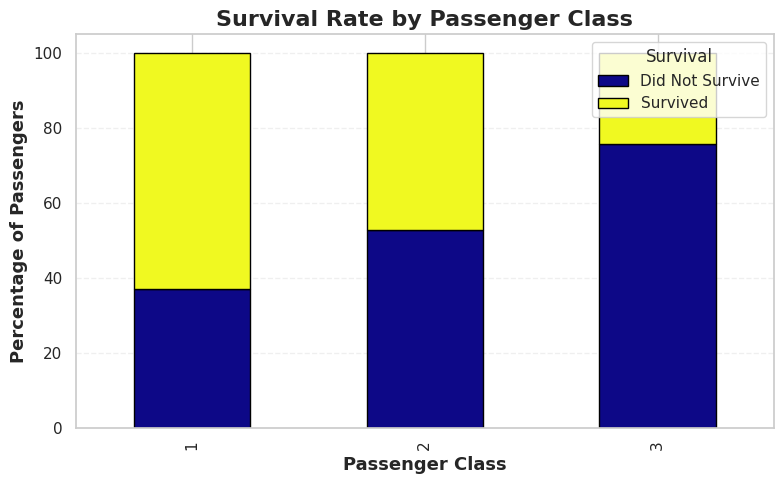

In [32]:
#passenger class and survival

survival_class = pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
) * 100

survival_class.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="plasma",
    edgecolor="black"
)

plt.title("Survival Rate by Passenger Class", fontsize=16, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=13, fontweight="bold")
plt.ylabel("Percentage of Passengers", fontsize=13, fontweight="bold")

plt.legend(title="Survival", labels=["Did Not Survive", "Survived"])

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Explanation of the above plot:

This stacked bar chart compares survival rates across the three passenger classes. **First-class passengers had the highest survival rate**, with nearly two-thirds surviving. Survival decreased in second class and was the lowest in **third class**, where most passengers did not survive.

The chart suggests that **passenger class had a strong influence on survival**, with those in higher classes having a better chance of surviving the disaster.

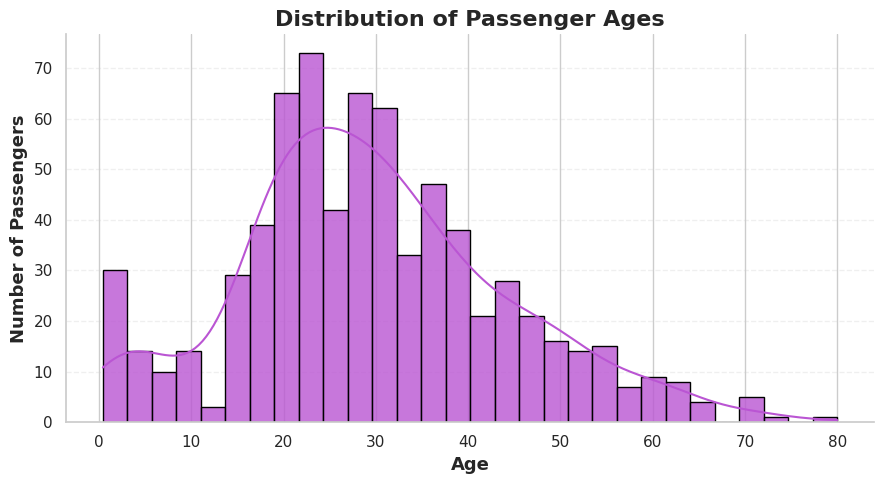

In [33]:
#age distribution

plt.figure(figsize=(9,5))

sns.histplot(
    data=train,
    x="Age",
    bins=30,
    kde=True,
    color="mediumorchid",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Passenger Ages", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize=13, fontweight="bold")
plt.ylabel("Number of Passengers", fontsize=13, fontweight="bold")

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This histogram shows the distribution of passenger ages on the Titanic. Most passengers were **between 20 and 35 years old**, with the highest concentration around the mid-20s. There were fewer children and elderly passengers compared to young adults.

The distribution is slightly right-skewed, indicating that while passengers of all ages were onboard, the majority were young adults.

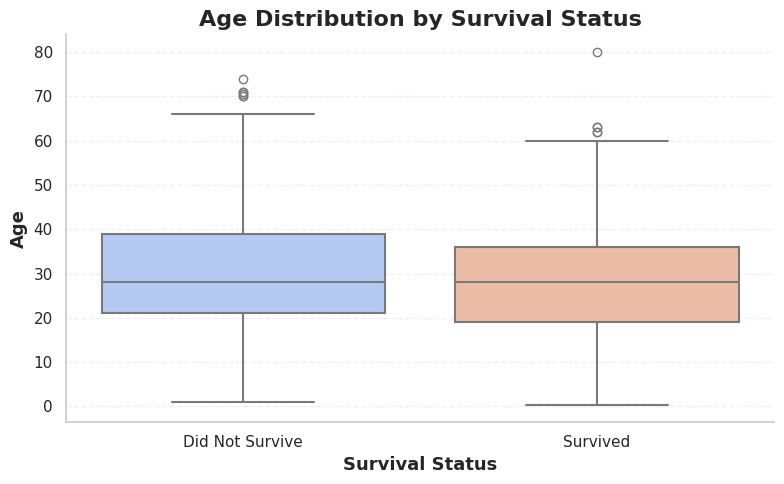

In [34]:
#age vs survival

plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x="Survived",
    y="Age",
    hue="Survived",
    palette="coolwarm",
    legend=False,
    linewidth=1.5
)

plt.title("Age Distribution by Survival Status", fontsize=16, fontweight="bold")
plt.xlabel("Survival Status", fontsize=13, fontweight="bold")
plt.ylabel("Age", fontsize=13, fontweight="bold")

plt.xticks([0,1], ["Did Not Survive", "Survived"])

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

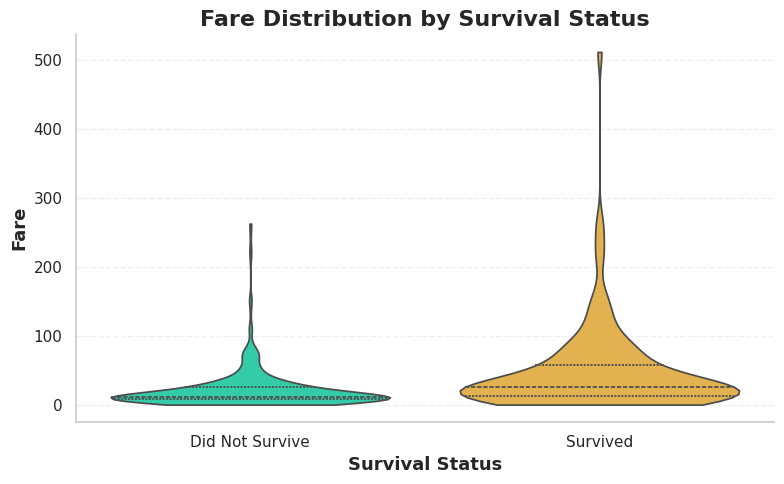

In [35]:
#fare vs survival

plt.figure(figsize=(8,5))

sns.violinplot(
    data=train,
    x="Survived",
    y="Fare",
    hue="Survived",
    palette="turbo",
    legend=False,
    inner="quartile",
    cut=0
)

plt.title("Fare Distribution by Survival Status", fontsize=16, fontweight="bold")
plt.xlabel("Survival Status", fontsize=13, fontweight="bold")
plt.ylabel("Fare", fontsize=13, fontweight="bold")

plt.xticks([0, 1], ["Did Not Survive", "Survived"])

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

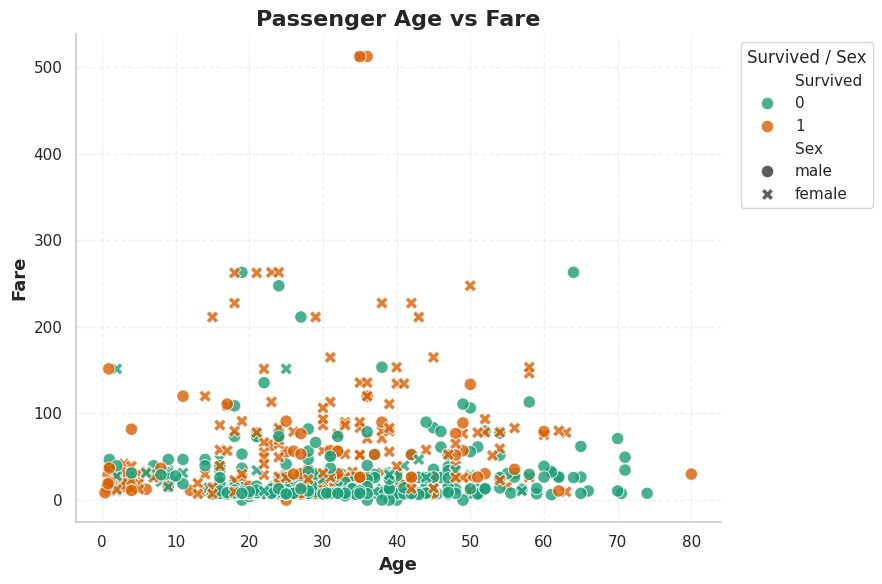

In [36]:
#age and fare relationship

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=train,
    x="Age",
    y="Fare",
    hue="Survived",
    style="Sex",
    palette="Dark2",
    s=80,
    alpha=0.8
)

plt.title("Passenger Age vs Fare", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize=13, fontweight="bold")
plt.ylabel("Fare", fontsize=13, fontweight="bold")

plt.legend(title="Survived / Sex", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This scatter plot shows the relationship between **passenger age** and **ticket fare**, while also indicating **survival status** and **gender**. Most passengers paid lower fares regardless of age, although a few passengers paid exceptionally high fares.

There is no strong relationship between age and ticket fare, but passengers who paid higher fares appear to have survived more often. This suggests that factors such as **ticket class**, rather than age alone, played a larger role in survival.

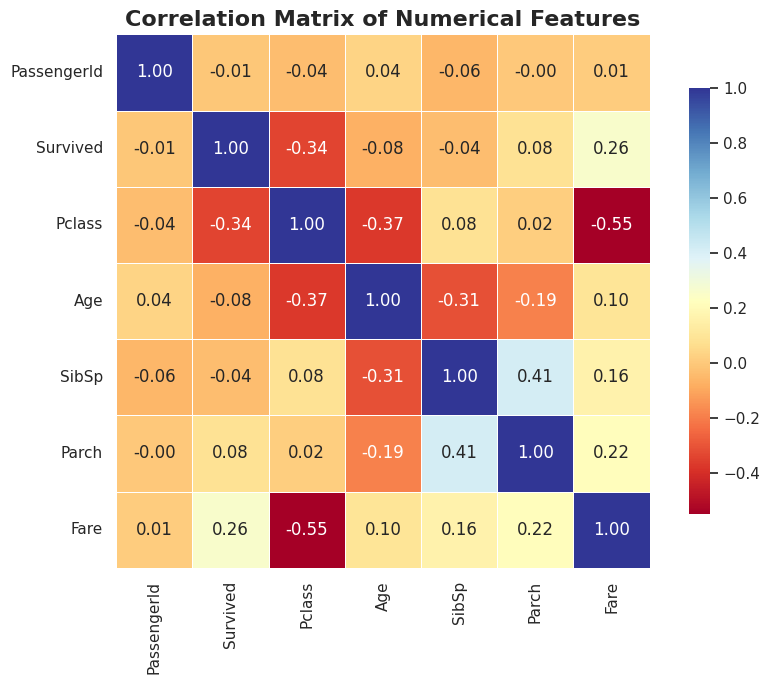

In [37]:
#correlation heatmap

plt.figure(figsize=(9,7))

numeric_data = train.select_dtypes(include=["number"])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

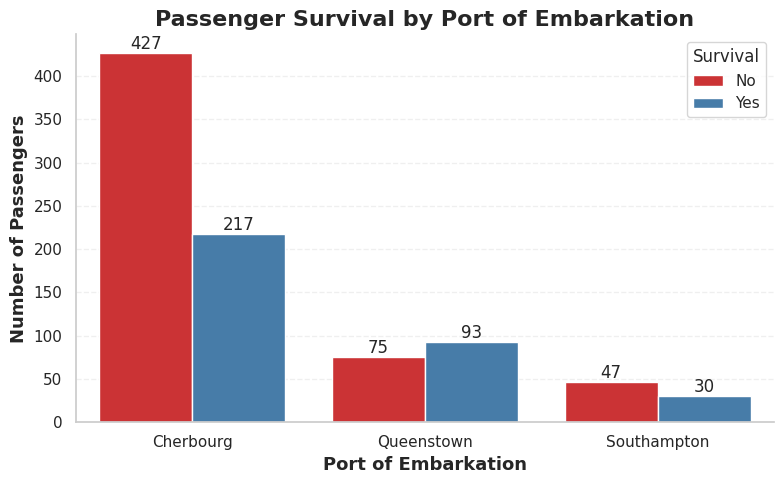

In [38]:
#embarked vs survival

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=train,
    x="Embarked",
    hue="Survived",
    palette="Set1"
)

plt.title("Passenger Survival by Port of Embarkation", fontsize=16, fontweight="bold")
plt.xlabel("Port of Embarkation", fontsize=13, fontweight="bold")
plt.ylabel("Number of Passengers", fontsize=13, fontweight="bold")

plt.xticks([0,1,2], ["Cherbourg", "Queenstown", "Southampton"])

plt.legend(title="Survival", labels=["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Section 5: Misleading Visualizations

Not all visualizations communicate data effectively. The way information is presented can sometimes make patterns appear more or less important than they actually are. In this section, two examples of **misleading visualizations** are used to demonstrate how poor chart choices can make data more difficult to interpret, even when the underlying data is correct.

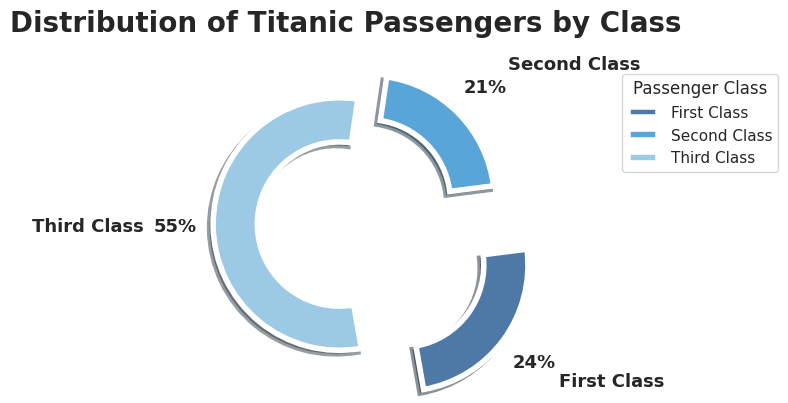

In [39]:
#misleading pie chart

class_counts = train["Pclass"].value_counts().sort_index()

labels = [
    "First Class",
    "Second Class",
    "Third Class"
]

colors = ["#4E79A7", "#59A5D8", "#9CC9E3"]

explode = (0.55, 0.25, 0.05)

plt.figure(figsize=(10,10))

plt.pie(
    class_counts,
    labels=labels,
    colors=colors,
    explode=explode,
    startangle=280,
    shadow=True,
    autopct="%1.0f%%",
    pctdistance=1.30,
    labeldistance=1.55,
    wedgeprops={
        "width":0.35,
        "edgecolor":"white",
        "linewidth":4
    },
    textprops={
        "fontsize":13,
        "fontweight":"bold"
    }
)

plt.title(
    "Distribution of Titanic Passengers by Class",
    fontsize=20,
    fontweight="bold",
    pad=25
)

plt.legend(
    title="Passenger Class",
    bbox_to_anchor=(1.35,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This donut chart shows the distribution of passengers across the three ticket classes. While it correctly indicates that **third-class passengers made up the largest group (55%)**, the circular layout makes it harder to accurately compare the sizes of the remaining categories.

This is a misleading visualization because people tend to compare angles and areas less accurately than lengths. A simple bar chart would make the differences between passenger classes much easier to interpret.

In [40]:
#sankey diagram

import plotly.graph_objects as go

male_survived = len(train[(train["Sex"]=="male") & (train["Survived"]==1)])
male_died = len(train[(train["Sex"]=="male") & (train["Survived"]==0)])

female_survived = len(train[(train["Sex"]=="female") & (train["Survived"]==1)])
female_died = len(train[(train["Sex"]=="female") & (train["Survived"]==0)])

fig = go.Figure(data=[go.Sankey(

    node=dict(
        pad=25,
        thickness=25,
        line=dict(color="black", width=1),
        label=[
            "Male",
            "Female",
            "Did Not Survive",
            "Survived"
        ],
        color=[
            "#4C78A8",
            "#F28EAE",
            "#EF476F",
            "#06D6A0"
        ]
    ),

    link=dict(
        source=[0,0,1,1],
        target=[2,3,2,3],
        value=[
            male_died,
            male_survived,
            female_died,
            female_survived
        ],
        color=[
            "rgba(239,71,111,0.5)",
            "rgba(6,214,160,0.5)",
            "rgba(239,71,111,0.5)",
            "rgba(6,214,160,0.5)"
        ]
    )

)])

fig.update_layout(
    title={
        "text":"Titanic Survival Flow by Gender",
        "x":0.5,
        "font":{"size":22}
    },
    font=dict(size=14),
    width=900,
    height=600
)

fig.show()

### Explanation of the above plot:

This Sankey diagram illustrates the flow of passengers from **gender** to **survival outcome**. Although it contains the correct information, the varying flow widths and overlapping colors make it difficult to compare the number of survivors and non-survivors between males and females.

This is a misleading visualization because it is more visually complex than necessary. A grouped or stacked bar chart communicates the same information much more clearly and allows for easier comparison between the two groups.

# Section 4: Effective Visualizations

Choosing the right visualization makes it easier to identify patterns and communicate insights. The following plots use appropriate chart types to clearly present relationships within the Titanic dataset, helping highlight the factors that influenced passenger survival.

/tmp/ipykernel_4121/3348485001.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



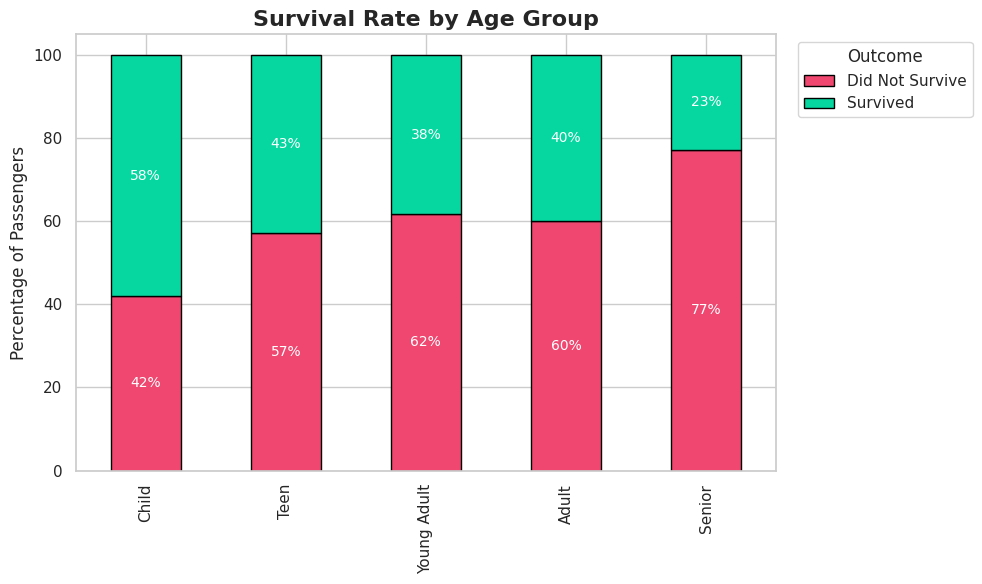

In [41]:
#survival by age group

train["Age Group"] = pd.cut(
    train["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

age_survival = (
    train.groupby("Age Group")["Survived"]
    .value_counts(normalize=True)
    .unstack()*100
)

ax = age_survival.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#EF476F","#06D6A0"],
    edgecolor="black"
)

plt.title("Survival Rate by Age Group",fontsize=16,fontweight="bold")
plt.xlabel("")
plt.ylabel("Percentage of Passengers")

plt.legend(
    ["Did Not Survive","Survived"],
    title="Outcome",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f%%",label_type="center",fontsize=10,color="white")

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This stacked bar chart compares survival rates across different age groups. **Children had the highest survival rate (58%)**, while **seniors had the lowest (23%)**. The remaining age groups experienced survival rates between **38% and 43%**.

This is an effective visualization because it makes it easy to compare survival percentages across age groups. The stacked percentages clearly show how survival varied with age while keeping each group on the same scale.

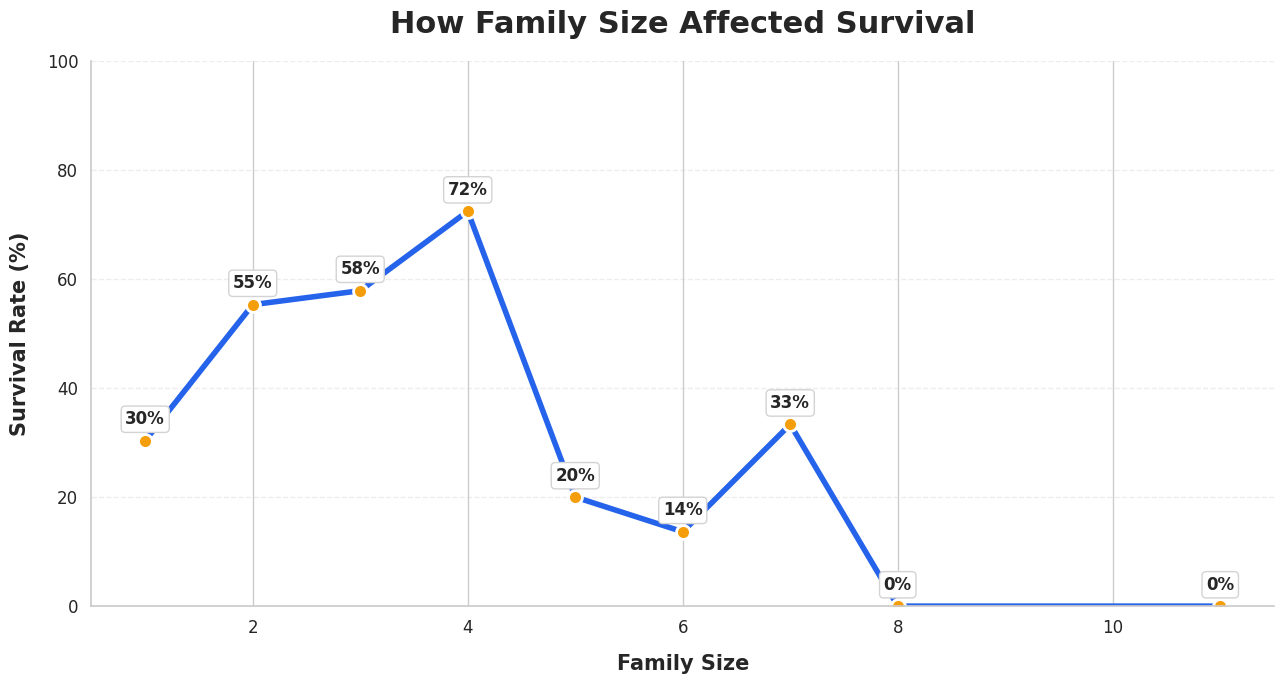

In [42]:
#family size vs survival

train["Family Size"] = train["SibSp"] + train["Parch"] + 1

family = train.groupby("Family Size")["Survived"].mean() * 100

plt.figure(figsize=(13,7))

plt.plot(
    family.index,
    family.values,
    color="#2563EB",
    linewidth=4,
    marker="o",
    markersize=10,
    markerfacecolor="#F59E0B",
    markeredgecolor="white",
    markeredgewidth=2
)

for x, y in zip(family.index, family.values):
    plt.text(
        x,
        y + 3,
        f"{y:.0f}%",
        ha="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.25"
        )
    )

plt.title(
    "How Family Size Affected Survival",
    fontsize=22,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Family Size",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

plt.ylabel(
    "Survival Rate (%)",
    fontsize=15,
    fontweight="bold",
    labelpad=12
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(0.5, 11.5)
plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.35)

sns.despine()

plt.tight_layout()
plt.show()

### Explanation of the above plot:

This line chart shows how survival rates changed with different family sizes. Passengers traveling with **2 to 4 family members** had the highest survival rates, peaking at **72% for a family size of 4**. In contrast, passengers traveling in very large families had much lower survival rates.

This is an effective visualization because it clearly highlights the trend between family size and survival. The line makes it easy to see that moderate-sized families generally had better survival outcomes than passengers traveling alone or in very large groups.

# Section 6: Conclusion

This analysis showed that **gender, passenger class, age, and family size** all had a noticeable impact on survival during the Titanic disaster. For example, **58% of children survived compared to only 23% of seniors**, **first-class passengers had much higher survival rates than third-class passengers**, and passengers traveling with **four family members had the highest survival rate at 72%**. These visualizations made the patterns easy to identify within a few seconds.

The misleading visualizations, however, told a different story. Although they used the same data, the **donut chart** made comparing passenger classes less intuitive, and the **Sankey diagram** looked impressive but required much more effort to interpret. Sometimes a chart can be visually appealing without actually helping the audience. After all, if a graph takes longer to understand than the Titanic took to hit the iceberg... it might not be the best choice.

Overall, this project demonstrates that effective visualizations do more than display data—they communicate it. Choosing the right chart allows important patterns to stand out, while poor visualization choices can hide valuable insights even when the underlying data is completely accurate.